<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5221: Intelligent Image and Video Analysis</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 4.1: Image Segmentation</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Image Segmentation**

In object recognition, there are four types of segmentation:

| Type | Description |
|---|---|
| Semantic Segmentation | Assigns a class label to every pixel in the image |
| Classification & Localisation | Predicts the location and class of a single object |
| Object Detection | Detects multiple objects along with their classes and locations |
| Instance Segmentation | Combines pixel-level labelling with detection of multiple object classes and locations |

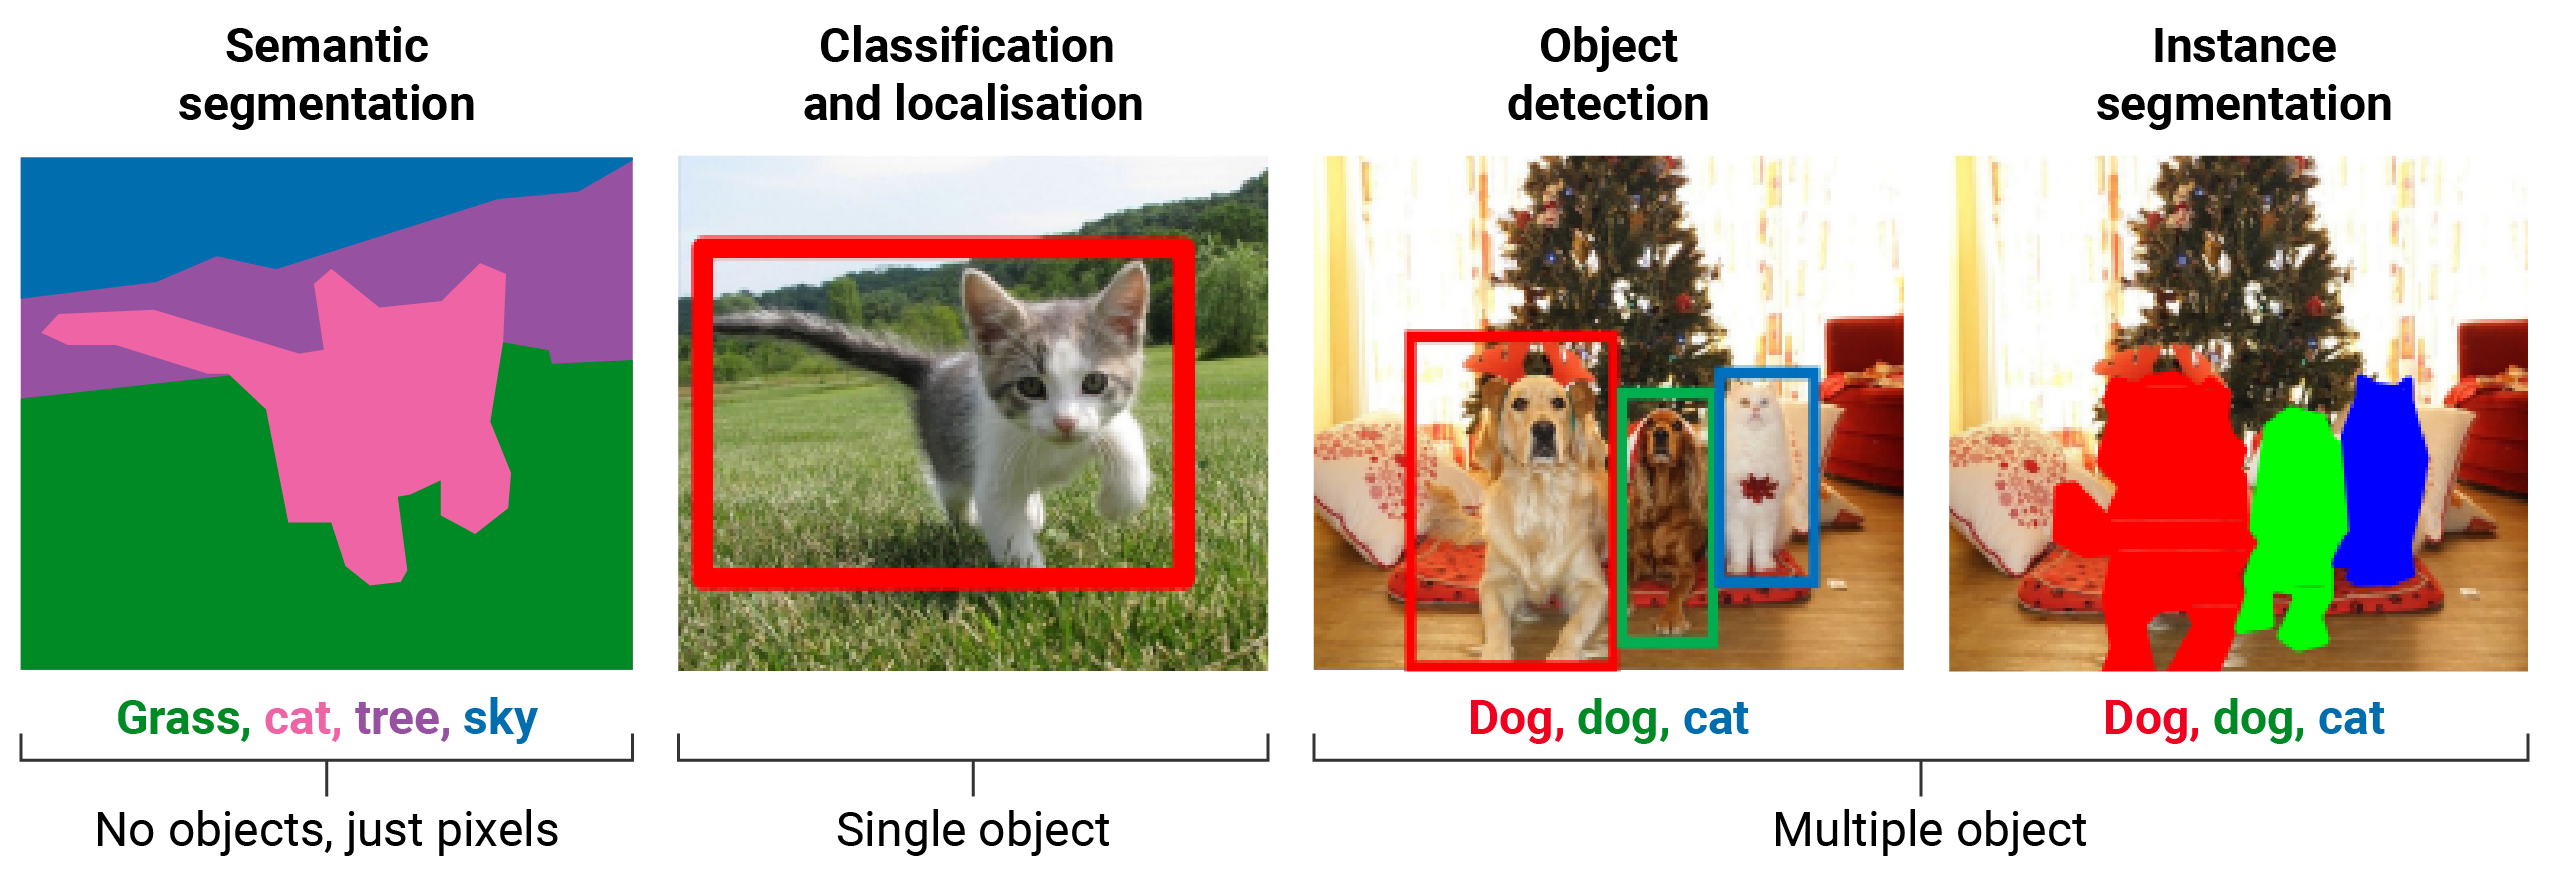

*Source: Four types of segmentation (2022) courtesy of the Faculty of Information Technology*

In this module, we focus on the first task — **semantic segmentation**.

Given an input image, segmentation classifies each pixel into a category. The goal is to partition the image into coherent "objects", which involves two core processes:

- **Bottom-up:** group pixels that share similar visual features
- **Top-down:** group pixels that likely belong to the same object

Both approaches aim to:
1. **Gather features** that belong together
2. **Produce a compact intermediate representation** that describes the key parts of the image (or video)

#### **Top-Down vs. Bottom-Up**

| Approach | Grouping Rationale |
|---|---|
| Top-down | Pixels belong together because they come from the same object |
| Bottom-up | Pixels belong together because they look similar |

<br>

### **Simple Segmentation Example**

Consider an image containing two objects on a white background — a black circle and a grey square that slightly overlap. Each region has a distinct intensity, giving us three groups:

A histogram of pixel intensities would show three distinct peaks, one for each group. We could label every pixel according to which of these primary intensities it belongs to.

But what happens when the image is more complex, for example, if we add noise? The intensity plot becomes messier and it is no longer obvious where the three main groups are. This is where **clustering** comes in.

<br>

### **The Goal of Clustering**

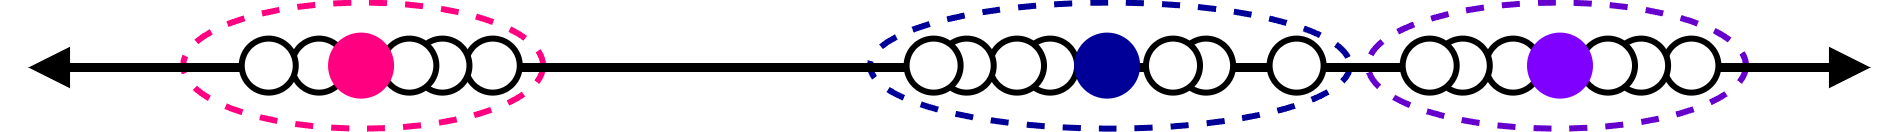

The idea is to choose $k$ representative centres and assign every pixel to its nearest centre. The best cluster centres are those that **minimize the total distance** between all points and their assigned centre.

$$\sum_{\text{clusters } i} \sum_{\text{points } p \text{ in cluster } i} \|p - c_i\|^2$$

Where:
- $c_i$ = the centre of cluster $i$
- $p$ = a data point (e.g., a pixel intensity) assigned to cluster $i$
- $\|p - c_i\|^2$ = the squared distance between point $p$ and its cluster centre

In other words, we want each point as close as possible to the centre it is assigned to. A basic algorithm for solving this is **K-Means**, which will be discussed next.

---

### **Clustering by K-Means**

K-Means is a widely used clustering algorithm. The core idea is to randomly initialise $k$ cluster centres, then iteratively refine them using the steps below.

#### **The Algorithm**

#### **Algorithm Steps**
1. **Initialize:** Select K value and randomly place K cluster centroids in the equipment parameter space
2. **Assignment:** Assign each equipment unit to the nearest centroid based on operational similarity
3. **Update:** Recalculate each centroid as the mean of all equipment units in that cluster
4. **Convergence Check:** If no equipment units change clusters, algorithm terminates
5. **Iterate:** Otherwise, return to step 2

#### **Industrial Implementation Example**
**Scenario:** Classifying 50 industrial motors using power consumption and vibration levels

**Step 1 - Initialization (K=3):**
- Randomly place 3 centroids in power-vibration parameter space
- Each centroid represents a potential object classification

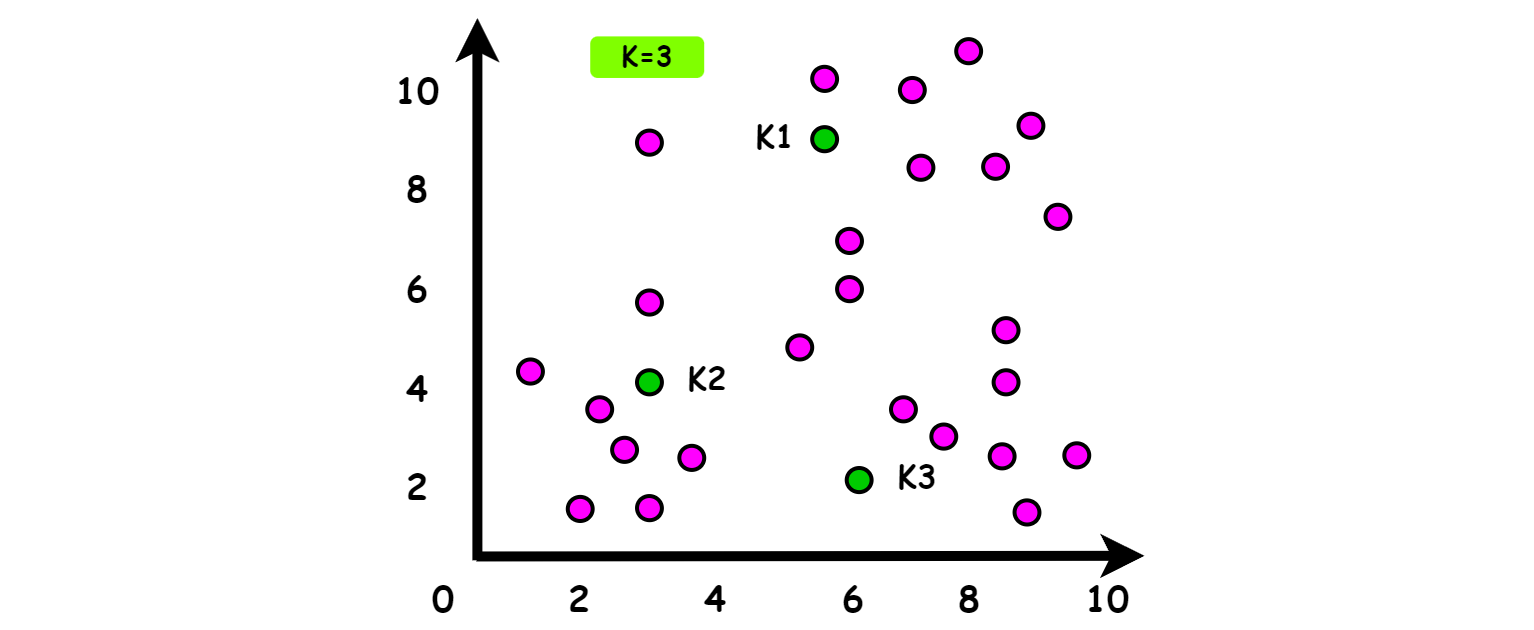

<br>

**Step 2 - Equipment Assignment:**
- Calculate distance from each object to all 3 centroids
- Assign each object to closest centroid cluster

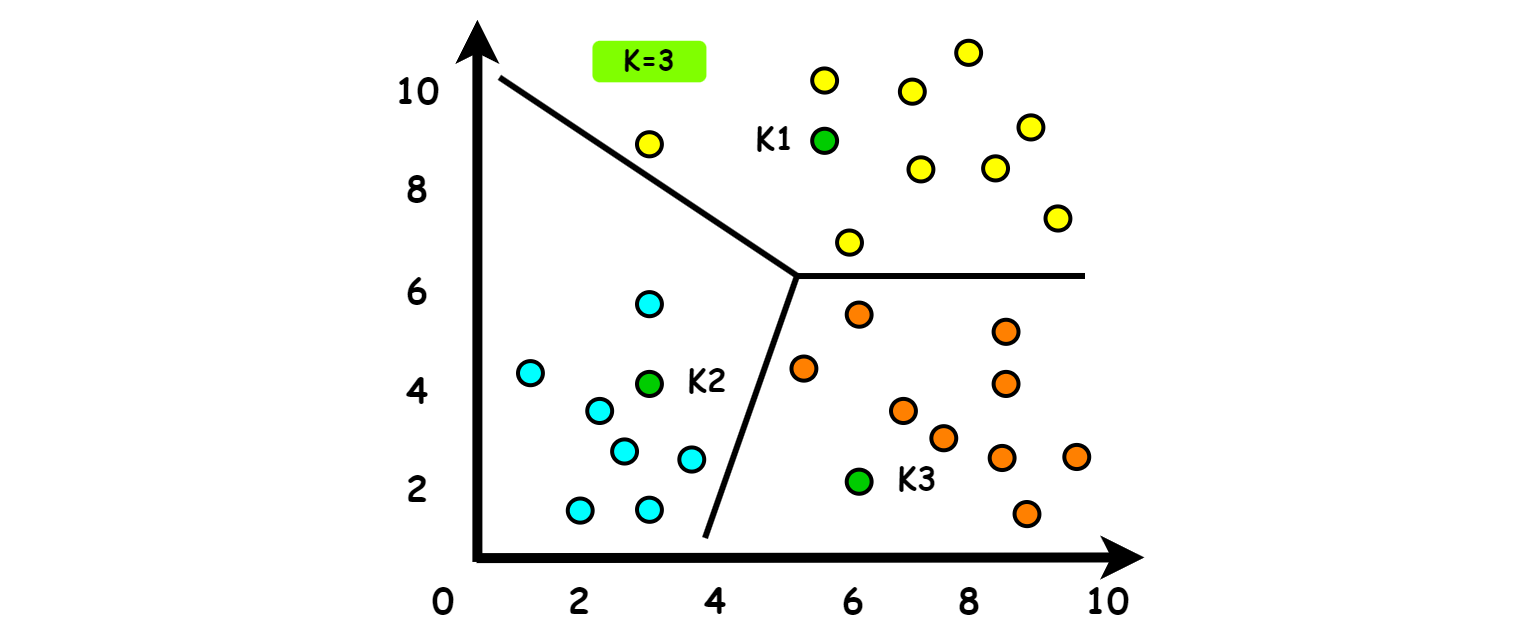

<br>

**Step 3 - Centroid Recalculation:**
- For each cluster, compute average x and y values
- Move centroid to this average position

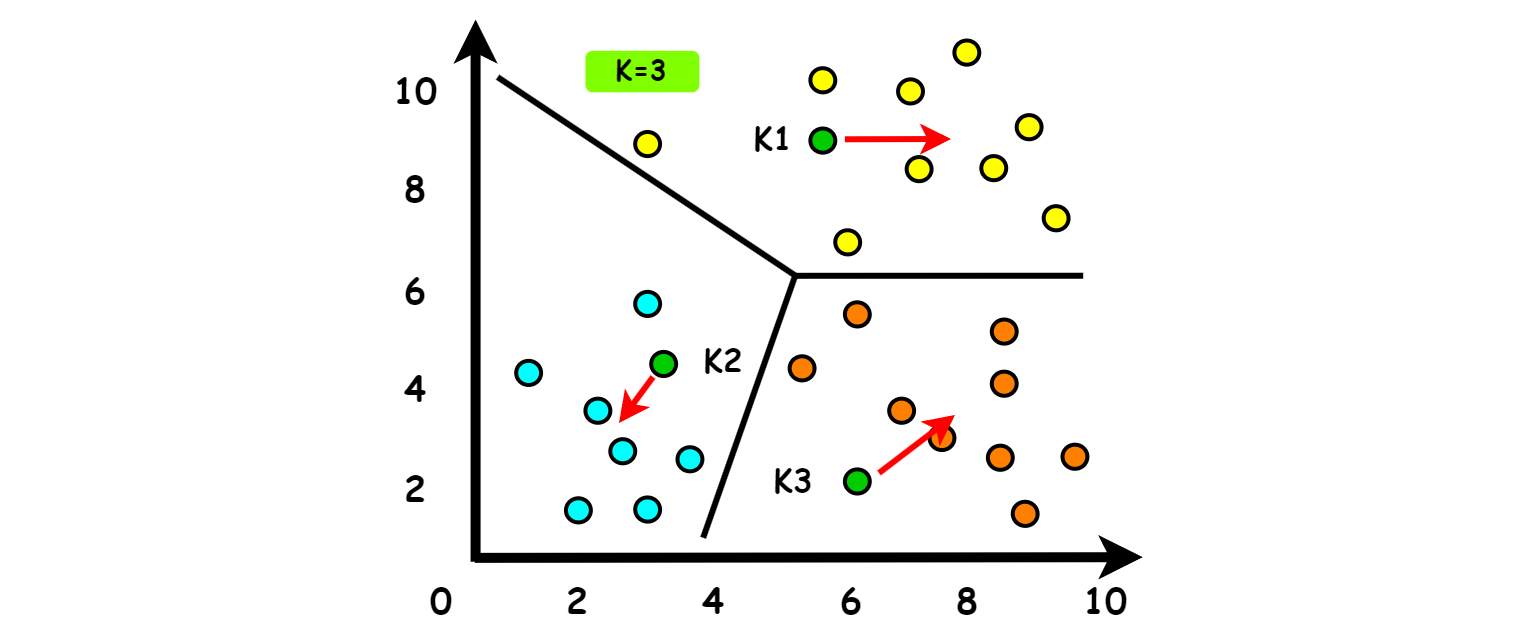

<br>

**Step 4 - Iteration:**
- Repeat assignment and update until object classifications stabilize

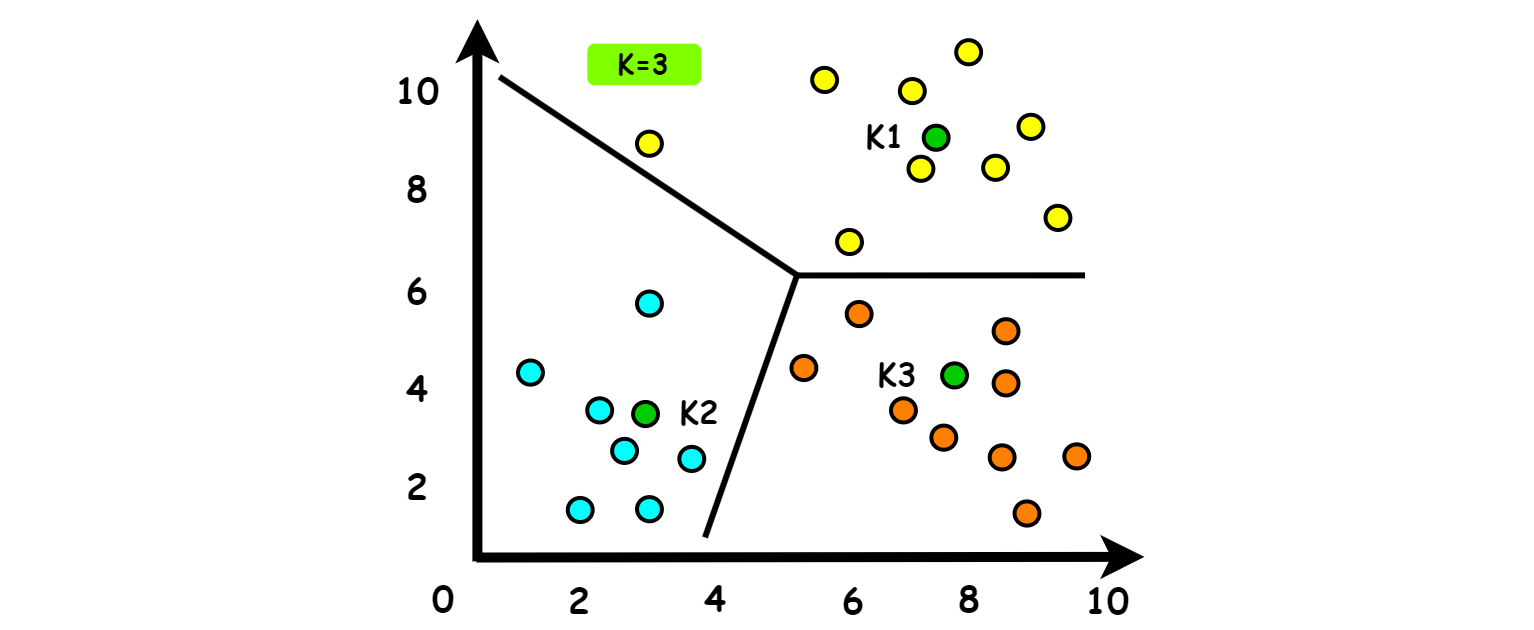

<br>

#### **Properties**

- The algorithm is **guaranteed to converge** to some solution
- However, it may converge to a **local minimum** — not necessarily the global minimum of the objective function

<br>

#### **Pros and Cons of K-Means**

| Pros | Cons |
|---|---|
| Simple and fast to compute | $k$ is a hyperparameter that must be set manually |
| Converges to a local minimum of within-cluster squared error | Sensitive to the choice of initial centres |
| | Sensitive to outliers |
| | Can only detect spherical (globular) clusters |
| | Assumes that a mean can be meaningfully computed |

<br>

#### **Limitations — Two Examples**

**Example 1 — Outlier Sensitivity:**
Consider a scatterplot with two natural groups and one outlier far from both. In the ideal clustering, the outlier is excluded from the nearby cluster. However, K-Means may pull a cluster centre toward the outlier, causing nearby points to be wrongly assigned. Points that are close together end up in different clusters because the outlier distorts the centre.

**Example 2 — Non-Linear Boundaries:**
Consider two clusters that are naturally separated by a curved boundary rather than a straight line. Since K-Means divides space using linear boundaries (each point goes to its nearest centre), it cannot correctly separate clusters that require a non-linear decision boundary.

---

### **Clustering as Segmentation**

We can apply clustering algorithms like K-Means to perform image segmentation. For instance, a greyscale image of a panda can be segmented by clustering pixels based on **intensity similarity**. If the image is in colour, we can instead group pixels based on **colour similarity**.

The choice of feature space determines the type of pixel groupings we get.

<br>

#### **Intensity and Position**

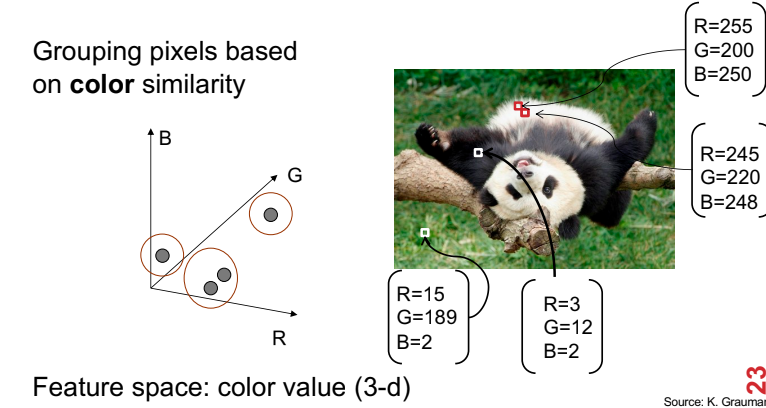

*Source: Clustering for image segmentation: intensity/colour (2022) courtesy of the Faculty of Information Technology*

Clusters based purely on intensity similarity do not have to be **spatially coherent** — pixels with the same intensity could be scattered across the image. To address this, we can group pixels based on both intensity (or colour) **and** position.

However, using colour, brightness, and position alone is still not enough to distinguish all regions.

<br>

#### **Texture-Based Grouping**

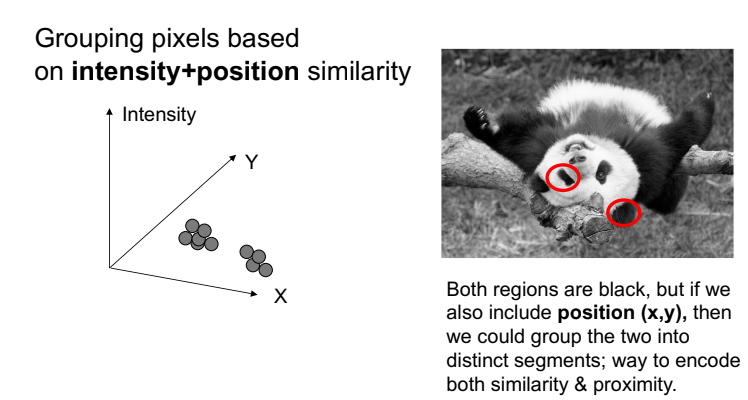

*Source: Clustering for image segmentation: position (2022) courtesy of the Faculty of Information Technology*

Consider two cases: an animal with a textured skin pattern, and clothing with a repeating polka-dot pattern. These regions share similar textures that colour or intensity alone cannot separate.

To handle this, we can group pixels based on **features extracted from filter banks**. A filter bank produces a high-dimensional feature vector for each pixel (e.g., a 24-dimensional response vector). Clustering in this feature space groups pixels by texture similarity rather than just colour.

$$\text{Feature space: filter bank responses (e.g., 24-d)}$$

For example, given an image of a zebra in a grassland:
- **Texture-based clustering** separates the zebra's stripes from the grass, producing more semantically meaningful regions
- **Colour-based clustering** may merge visually different regions that happen to share similar colours

As a general observation, texture-based clustering tends to generate more **context-relevant** segments than colour-based clustering alone.

---

### **Deep Learning and Segmentation**

#### **Fully Convolutional Networks (FCN)**

Introduced in 2015, **Fully Convolutional Networks (FCN)** take an image as input and produce **pixel-wise predictions**. Segmentation with this architecture takes less than 0.2 seconds per image. It is also an **end-to-end** learning approach — the model trains directly from raw input images to output segmentation maps, with no separate steps in between.

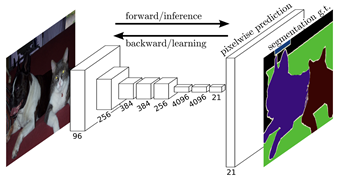

*Source: Fully Convolutional Network (2015) <https://bit.ly/3K5af0M>*

<br>

#### **CNN Classifier vs. FCN**

A standard **CNN classifier** (e.g., for ImageNet) has the following structure:
1. An input image is fed through several **convolutional layers** and **subsampling (pooling) layers** to extract features
2. The output is then passed through **fully connected layers** to predict a single class label

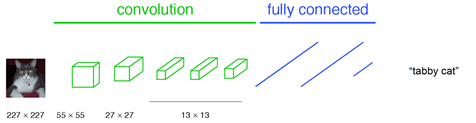

*Source: CNN classifier for ImageNet (2015) <https://bit.ly/3K5af0M>*

In an **FCN**, the fully connected layers are **replaced with convolutional layers**. At the final stage, an **upsampling layer** increases the spatial dimensions of the feature maps back to the original image size, producing a per-pixel output instead of a single label.

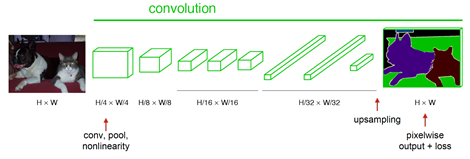

*Source: FCN classifier for ImageNet (2015) <https://bit.ly/3K5af0M>*

| Component | CNN Classifier | FCN |
|---|---|---|
| Feature extraction | Convolutional + pooling layers | Convolutional + pooling layers |
| Prediction layers | Fully connected layers | Convolutional layers |
| Output | Single class label | Pixel-wise segmentation map |
| Upsampling | None | Applied at the final layer |

<br>

#### **U-Net**

**U-Net** is a related architecture originally introduced for **medical image analysis**. It consists of two parts:

1. **Contraction path (encoder):** progressively reduces spatial resolution to capture context
2. **Expansion path (decoder):** progressively increases resolution to recover spatial detail

At each resolution level, there are **skip connections** between the contraction and expansion paths, allowing fine-grained details from earlier layers to be combined with deeper, more abstract features.

#### **Key Difference: U-Net vs. FCN**

| | FCN | U-Net |
|---|---|---|
| Upsampling strategy | Increases resolution in **one step** | Increases resolution **gradually** across multiple layers |
| Skip connections | Not emphasised | Connects matching resolution levels between encoder and decoder |

The gradual upsampling in U-Net helps preserve spatial detail, which is especially important in applications like medical imaging where precise boundaries matter.